# Group Query Attention (GQA) — Math, Code & Visualization

---

## The Attention Family

| Method | Q heads | K heads | V heads | KV-cache cost |
|---|---|---|---|---|
| **MHA** | $H$ | $H$ | $H$ | $O(H \cdot s_k \cdot d_{head})$ |
| **MQA** | $H$ | $1$ | $1$ | $O(s_k \cdot d_{head})$ |
| **GQA** | $H$ | $G$ | $G$ | $O(G \cdot s_k \cdot d_{head})$ |

GQA (Ainslie et al. 2023) interpolates between MHA ($G=H$) and MQA ($G=1$) by grouping $H$ query heads into $G$ groups. Each group shares one K/V head.

---

## GQA Math

**Setup:** $H$ query heads, $G$ KV groups, $H/G$ = heads per group.

**Linear projections:**

$$Q_h = Q W_h^Q \in \mathbb{R}^{b \times s_l \times d_{head}}, \quad h = 1 \ldots H$$

$$K_g = K W_g^K \in \mathbb{R}^{b \times s_k \times d_{head}}, \quad g = 1 \ldots G$$

$$V_g = V W_g^V \in \mathbb{R}^{b \times s_k \times d_{head}}, \quad g = 1 \ldots G$$

**Group assignment:** head $h$ belongs to group $g(h) = \lceil h / (H/G) \rceil$.

**Attention for head $h$:**

$$\text{score}_h = \frac{Q_h \, K_{g(h)}^\top}{\sqrt{d_{head}}} \in \mathbb{R}^{b \times s_l \times s_k}$$

Apply mask $M$ (True = attend, False = block):

$$\text{score}_h[i,j] = \begin{cases} \text{score}_h[i,j] & M[i,j] = \text{True} \\ -\infty & M[i,j] = \text{False} \end{cases}$$

$$\alpha_h = \text{softmax}(\text{score}_h) \in \mathbb{R}^{b \times s_l \times s_k}$$

$$\text{head}_h = \alpha_h \, V_{g(h)} \in \mathbb{R}^{b \times s_l \times d_{head}}$$

**Final output** (concatenate all heads):

$$\text{GQA}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_H) \in \mathbb{R}^{b \times s_l \times d}$$

where $d = H \times d_{head}$.

---

## Implementation trick: `repeat_interleave`

Instead of routing each head to its group during the matmul, we expand K/V:

$$K_{\text{expanded}} = \text{repeat\_interleave}(K, H/G, \text{dim}=\text{head}) \in \mathbb{R}^{b \times H \times s_k \times d_{head}}$$

This lets us use a single batched matmul $Q \cdot K_{\text{expanded}}^\top$ for all heads at once.

## 1. Imports

In [1]:
from typing import Optional
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

## 2. Model Definition

In [2]:
class GroupQueryAttention(nn.Module):
    def __init__(self, hidden_dim: int, head_dim: int, group_num: int):
        super().__init__()

        self.head_dim   = head_dim
        self.hidden_dim = hidden_dim
        self.group_num  = group_num

        if hidden_dim % head_dim != 0:
            raise ValueError(f"hidden_dim ({hidden_dim}) must be divisible by head_dim ({head_dim})")
        self.head_num = hidden_dim // head_dim

        if self.head_num % group_num != 0:
            raise ValueError(f"head_num ({self.head_num}) must be divisible by group_num ({group_num})")
        self.head_per_group = self.head_num // group_num

        # Q: one projection per query head  → output hidden_dim
        self.map_q = nn.Linear(hidden_dim, hidden_dim)
        # K, V: one projection per GROUP   → output group_num * head_dim
        self.map_k = nn.Linear(hidden_dim, head_dim * group_num)
        self.map_v = nn.Linear(hidden_dim, head_dim * group_num)

    def forward(
        self,
        q: torch.Tensor,                      # (b, sl, hidden_dim)
        k: torch.Tensor,                      # (b, sk, hidden_dim)
        v: torch.Tensor,                      # (b, sk, hidden_dim)
        mask: Optional[torch.BoolTensor] = None,  # (1, 1, sl, sk) — True=attend
        return_weights: bool = False,
    ):
        b, sl, _ = q.shape
        _, sk, _ = k.shape

        # --- Linear projections ---
        q = self.map_q(q)  # (b, sl, hidden_dim)
        k = self.map_k(k)  # (b, sk, group_num * head_dim)
        v = self.map_v(v)  # (b, sk, group_num * head_dim)

        # --- Reshape into heads / groups ---
        q = q.view(b, sl, self.head_num,  self.head_dim).transpose(1, 2)
        # q: (b, head_num, sl, head_dim)
        k = k.view(b, sk, self.group_num, self.head_dim).transpose(1, 2)
        # k: (b, group_num, sk, head_dim)
        v = v.view(b, sk, self.group_num, self.head_dim).transpose(1, 2)
        # v: (b, group_num, sk, head_dim)

        # --- Expand K/V so every query head has a matching K/V ---
        # repeat_interleave copies each group head_per_group times
        k = k.repeat_interleave(self.head_per_group, dim=1)
        v = v.repeat_interleave(self.head_per_group, dim=1)
        # k, v: (b, head_num, sk, head_dim)

        # --- Scaled dot-product scores ---
        scale = self.head_dim ** 0.5
        score = torch.matmul(q, k.transpose(-2, -1)) / scale
        # score: (b, head_num, sl, sk)

        # --- Apply boolean mask (True=attend, False=block) ---
        if mask is not None:
            score = score.masked_fill(~mask, float("-inf"))

        # --- Softmax over key dimension ---
        attention_weight = torch.softmax(score, dim=-1)
        # attention_weight: (b, head_num, sl, sk)

        # --- Weighted sum of values ---
        output = torch.matmul(attention_weight, v)
        # output: (b, head_num, sl, head_dim)

        # --- Merge heads ---
        output = output.transpose(1, 2).contiguous().view(b, sl, self.hidden_dim)
        # output: (b, sl, hidden_dim)

        if return_weights:
            return output, attention_weight
        return output

## 3. Instantiate and check config

In [3]:
HIDDEN_DIM = 12
HEAD_DIM   = 2
GROUP_NUM  = 3
BATCH      = 1
SL         = 6   # query sequence length
SK         = 5   # key/value sequence length

model = GroupQueryAttention(HIDDEN_DIM, HEAD_DIM, GROUP_NUM)
print(model)
print(f"""
hidden_dim     = {model.hidden_dim}
head_dim       = {model.head_dim}
head_num       = {model.head_num}    (hidden_dim / head_dim)
group_num      = {model.group_num}
head_per_group = {model.head_per_group}    (head_num / group_num)
""")

GroupQueryAttention(
  (map_q): Linear(in_features=12, out_features=12, bias=True)
  (map_k): Linear(in_features=12, out_features=6, bias=True)
  (map_v): Linear(in_features=12, out_features=6, bias=True)
)

hidden_dim     = 12
head_dim       = 2
head_num       = 6    (hidden_dim / head_dim)
group_num      = 3
head_per_group = 2    (head_num / group_num)



## 4. Visualize group structure

Which query head belongs to which KV group?

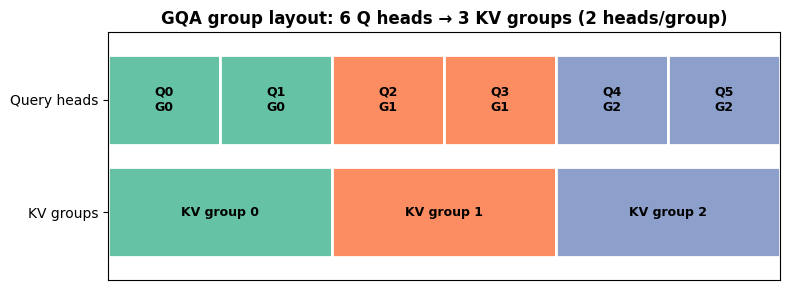

In [4]:
fig, ax = plt.subplots(figsize=(max(8, model.head_num * 1.2), 3))

colors = plt.cm.Set2.colors
for h in range(model.head_num):
    g = h // model.head_per_group
    ax.barh(0, 1, left=h, color=colors[g % len(colors)], edgecolor="white", linewidth=2)
    ax.text(h + 0.5, 0, f"Q{h}\nG{g}", ha="center", va="center", fontsize=9, fontweight="bold")

for g in range(model.group_num):
    start = g * model.head_per_group
    ax.barh(-1, model.head_per_group, left=start, color=colors[g % len(colors)],
            edgecolor="white", linewidth=2)
    ax.text(start + model.head_per_group / 2, -1, f"KV group {g}",
            ha="center", va="center", fontsize=9, fontweight="bold")

ax.set_xlim(0, model.head_num)
ax.set_ylim(-1.6, 0.6)
ax.set_yticks([0, -1])
ax.set_yticklabels(["Query heads", "KV groups"])
ax.set_xticks([])
ax.set_title(f"GQA group layout: {model.head_num} Q heads → {model.group_num} KV groups "
             f"({model.head_per_group} heads/group)", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Run WITHOUT a mask — attends to every position

Output shape        : torch.Size([1, 6, 12])
Attention wts shape : torch.Size([1, 6, 6, 5])


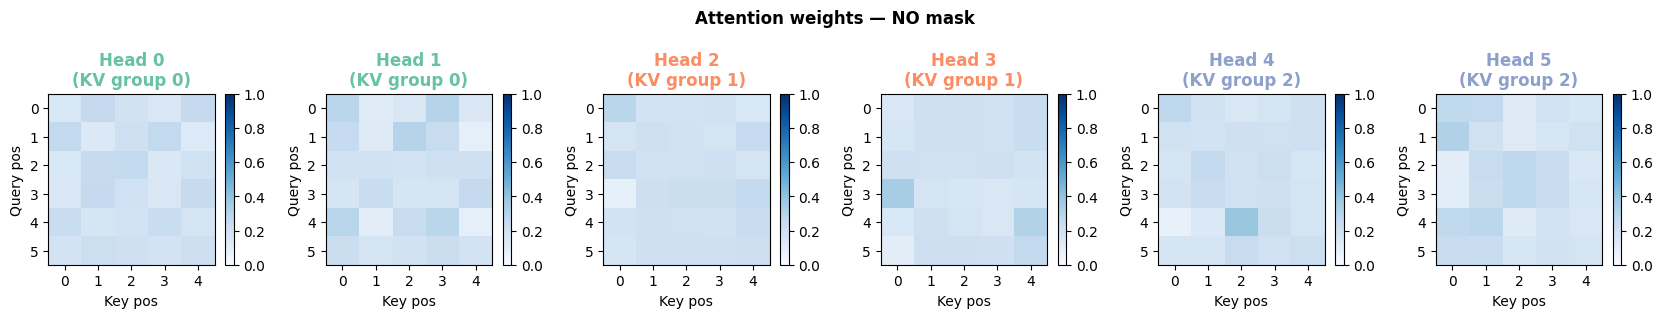

In [5]:
torch.manual_seed(0)
q = torch.randn(BATCH, SL, HIDDEN_DIM)
k = torch.randn(BATCH, SK, HIDDEN_DIM)
v = torch.randn(BATCH, SK, HIDDEN_DIM)

with torch.no_grad():
    out_no_mask, w_no_mask = model(q, k, v, mask=None, return_weights=True)

print("Output shape        :", out_no_mask.shape)   # (1, 6, 12)
print("Attention wts shape :", w_no_mask.shape)     # (1, head_num, 6, 5)


def plot_weights(weights, title):
    """weights: (head_num, sl, sk)"""
    head_num, sl, sk = weights.shape
    fig, axes = plt.subplots(1, head_num, figsize=(2.8 * head_num, 3.2))
    if head_num == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=12, fontweight="bold")
    colors = plt.cm.Set2.colors
    for h, ax in enumerate(axes):
        g = h // model.head_per_group
        im = ax.imshow(weights[h].numpy(), vmin=0, vmax=1,
                       cmap="Blues", aspect="auto")
        ax.set_title(f"Head {h}\n(KV group {g})",
                     color=colors[g % len(colors)], fontweight="bold")
        ax.set_xlabel("Key pos")
        ax.set_ylabel("Query pos")
        ax.set_xticks(range(sk))
        ax.set_yticks(range(sl))
        plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


plot_weights(w_no_mask[0].detach(), title="Attention weights — NO mask")

## 6. Run WITH a causal mask — query can only attend to earlier keys

Causal mask (sl × sk):
tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]], dtype=torch.int32)


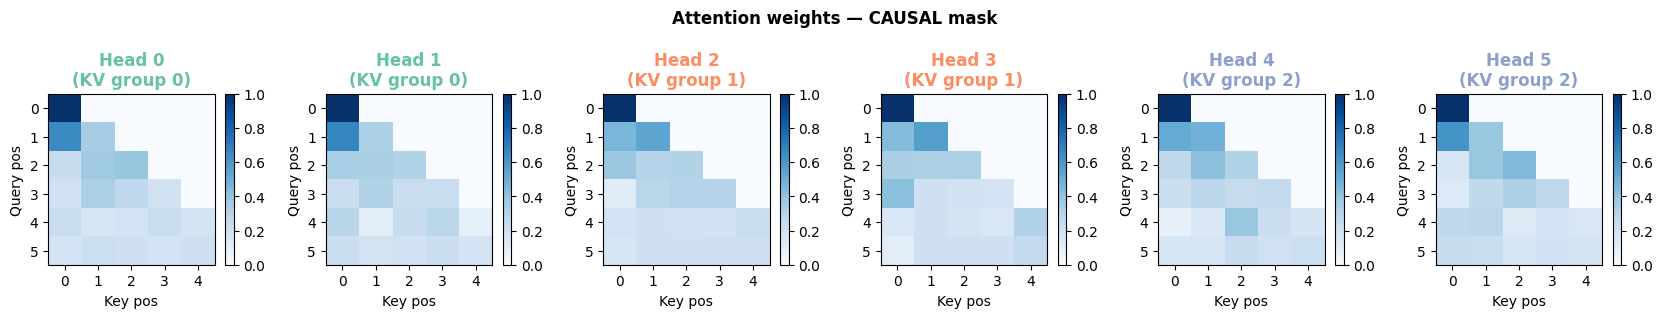

In [6]:
# Boolean mask: True = allowed, False = blocked
# Shape (1, 1, sl, sk) broadcasts to (b, head_num, sl, sk)
causal_mask = torch.ones(1, 1, SL, SK, dtype=torch.bool).tril()
print("Causal mask (sl × sk):")
print(causal_mask[0, 0].int())

with torch.no_grad():
    out_causal, w_causal = model(q, k, v, mask=causal_mask, return_weights=True)

plot_weights(w_causal[0].detach(), title="Attention weights — CAUSAL mask")

## 7. Run WITH a padding mask — last 2 key positions are padding

Padding mask (sl × sk):
tensor([[1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0]], dtype=torch.int32)


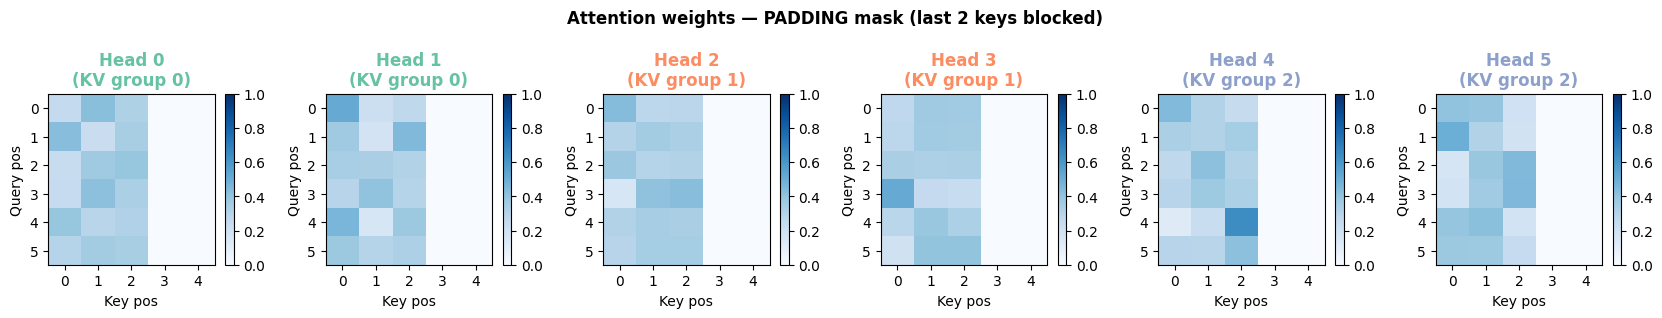

In [7]:
pad_mask = torch.ones(1, 1, SL, SK, dtype=torch.bool)
pad_mask[:, :, :, -2:] = False   # block last 2 key positions
print("Padding mask (sl × sk):")
print(pad_mask[0, 0].int())

with torch.no_grad():
    out_pad, w_pad = model(q, k, v, mask=pad_mask, return_weights=True)

plot_weights(w_pad[0].detach(), title="Attention weights — PADDING mask (last 2 keys blocked)")

## 8. Key insight: heads in the same group share K — but have different Q

Heads in the same group see the **same raw K scores** before Q scaling, but produce **different attention patterns** because Q differs per head.

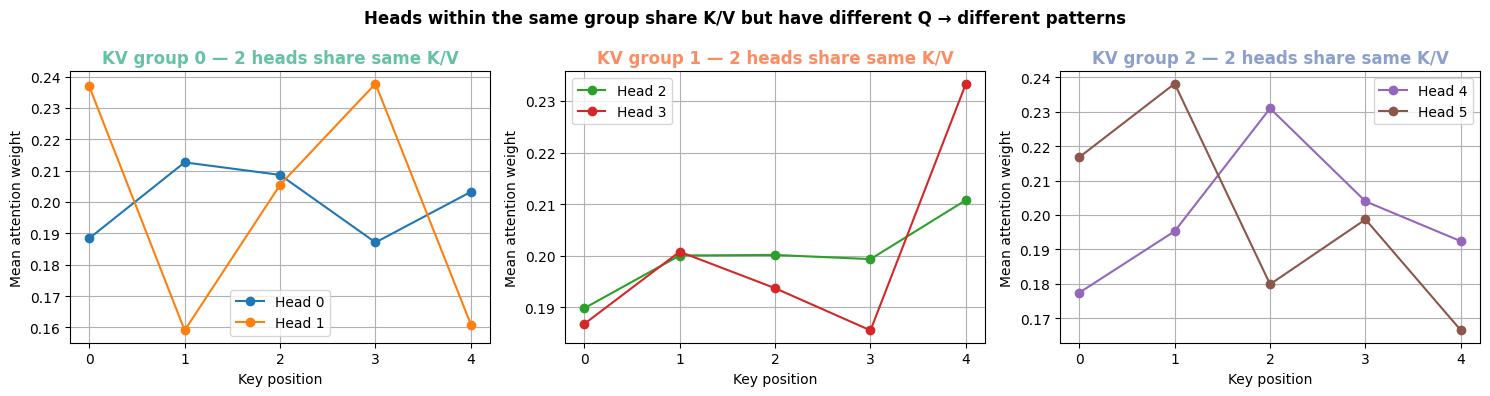

In [8]:
# Compare mean attention weight per key position, grouped by KV group
fig, axes = plt.subplots(1, model.group_num, figsize=(5 * model.group_num, 4))
colors_heads = plt.cm.tab10.colors
colors_groups = plt.cm.Set2.colors

w = w_no_mask[0].detach().numpy()  # (head_num, sl, sk)

for g, ax in enumerate(axes):
    for i in range(model.head_per_group):
        h = g * model.head_per_group + i
        mean_w = w[h].mean(axis=0)  # average over query positions
        ax.plot(mean_w, marker="o", label=f"Head {h}",
                color=colors_heads[h % len(colors_heads)])
    ax.set_title(f"KV group {g} — {model.head_per_group} heads share same K/V",
                 color=colors_groups[g % len(colors_groups)], fontweight="bold")
    ax.set_xlabel("Key position")
    ax.set_ylabel("Mean attention weight")
    ax.set_xticks(range(SK))
    ax.legend()
    ax.grid(True)

plt.suptitle("Heads within the same group share K/V but have different Q → different patterns",
             fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Tensor shape summary — every step

In [9]:
b, H, G, hpg, hd = BATCH, model.head_num, model.group_num, model.head_per_group, HEAD_DIM

print(f"Config: batch={b}, sl={SL}, sk={SK}, "
      f"hidden={HIDDEN_DIM}, head_dim={hd}, head_num={H}, group_num={G}, head_per_group={hpg}")
print()
print(f"Input  q:                 ({b}, {SL}, {HIDDEN_DIM})")
print(f"Input  k, v:              ({b}, {SK}, {HIDDEN_DIM})")
print()
print(f"After map_q(q):           ({b}, {SL}, {HIDDEN_DIM})         [H*head_dim]")
print(f"After map_k(k):           ({b}, {SK}, {G*hd})           [G*head_dim]")
print(f"After map_v(v):           ({b}, {SK}, {G*hd})           [G*head_dim]")
print()
print(f"Reshape q:                ({b}, {H}, {SL}, {hd})         (b, head_num, sl, head_dim)")
print(f"Reshape k:                ({b}, {G}, {SK}, {hd})          (b, group_num, sk, head_dim)")
print(f"Reshape v:                ({b}, {G}, {SK}, {hd})          (b, group_num, sk, head_dim)")
print()
print(f"After repeat_interleave:")
print(f"  k, v:                   ({b}, {H}, {SK}, {hd})         (b, head_num, sk, head_dim)")
print(f"  ← each group repeated {hpg}× to match {H} query heads")
print()
print(f"Scores:                   ({b}, {H}, {SL}, {SK})         (b, head_num, sl, sk)")
print(f"Attention weights:        ({b}, {H}, {SL}, {SK})         (b, head_num, sl, sk)")
print(f"Output (pre-merge):       ({b}, {H}, {SL}, {hd})         (b, head_num, sl, head_dim)")
print(f"Output (final):           ({b}, {SL}, {HIDDEN_DIM})        (b, sl, hidden_dim)")

Config: batch=1, sl=6, sk=5, hidden=12, head_dim=2, head_num=6, group_num=3, head_per_group=2

Input  q:                 (1, 6, 12)
Input  k, v:              (1, 5, 12)

After map_q(q):           (1, 6, 12)         [H*head_dim]
After map_k(k):           (1, 5, 6)           [G*head_dim]
After map_v(v):           (1, 5, 6)           [G*head_dim]

Reshape q:                (1, 6, 6, 2)         (b, head_num, sl, head_dim)
Reshape k:                (1, 3, 5, 2)          (b, group_num, sk, head_dim)
Reshape v:                (1, 3, 5, 2)          (b, group_num, sk, head_dim)

After repeat_interleave:
  k, v:                   (1, 6, 5, 2)         (b, head_num, sk, head_dim)
  ← each group repeated 2× to match 6 query heads

Scores:                   (1, 6, 6, 5)         (b, head_num, sl, sk)
Attention weights:        (1, 6, 6, 5)         (b, head_num, sl, sk)
Output (pre-merge):       (1, 6, 6, 2)         (b, head_num, sl, head_dim)
Output (final):           (1, 6, 12)        (b, sl, hidden_